# Pneumatic Systems Modeling, Simulation and Control

Includes a linearized control model plus nonlinear compressible-air cylinder dynamics with absolute chamber pressure, changing volume, dead volume, choked/subsonic valve flow, spool dynamics, leakage, asymmetric areas, friction, hard stroke limits, PID anti-windup, classical/state-space/digital control, Jacobian linearization and uncertainty sweeps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.linalg as la
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display

try:
    import control as ct
    HAS_CONTROL = True
except Exception as e:
    HAS_CONTROL = False
    print("Install python-control with: pip install control")
    print(e)

In [2]:
def stability_from_poles(poles, tol=1e-8):
    p=np.asarray(poles,dtype=complex)
    if np.any(np.real(p)>tol): return "UNSTABLE"
    if np.all(np.real(p)<-tol): return "ASYMPTOTICALLY STABLE"
    return "MARGINALLY STABLE"

def damping_label(zeta,tol=.02):
    if zeta < 0: return "UNSTABLE / NEGATIVE DAMPING"
    if abs(zeta)<1e-8: return "UNDAMPED"
    if zeta < 1-tol: return "UNDERDAMPED"
    if zeta <= 1+tol: return "CRITICALLY DAMPED (approximately)"
    return "OVERDAMPED"

def modal_label(poles):
    p=np.asarray(poles,dtype=complex)
    st=stability_from_poles(p)
    cp=[z for z in p if abs(np.imag(z))>1e-8]
    if cp:
        d=max(cp,key=lambda z:np.real(z))
        zeta=-np.real(d)/abs(d)
        if st=="UNSTABLE": return "OSCILLATORY UNSTABLE",st,zeta
        if zeta<.98: return "UNDERDAMPED",st,zeta
        if zeta<=1.02: return "CRITICALLY DAMPED-LIKE",st,zeta
        return "OVERDAMPED-LIKE",st,zeta
    return ("OVERDAMPED-LIKE / NON-OSCILLATORY" if st=="ASYMPTOTICALLY STABLE" else st),st,None

def metrics(t,y,final=None):
    t=np.asarray(t); y=np.asarray(y)
    if final is None: final=y[-1]
    peak_i=int(np.argmax(y)); peak=y[peak_i]
    overshoot=np.nan if abs(final)<1e-12 else max(0,(peak-final)/abs(final)*100)
    def cross(level):
        idx=np.where(y>=level)[0] if final>=0 else np.where(y<=level)[0]
        return t[idx[0]] if len(idx) else np.nan
    t10,t90=cross(.1*final),cross(.9*final)
    rise=t90-t10 if np.isfinite(t10) and np.isfinite(t90) else np.nan
    band=.02*max(abs(final),1e-12)
    out=np.where(np.abs(y-final)>band)[0]
    settle=0 if len(out)==0 else (t[out[-1]+1] if out[-1]<len(t)-1 else np.nan)
    return dict(rise_time=rise,settling_time=settle,peak_time=t[peak_i],overshoot_percent=overshoot,peak_value=peak)

def routh_table(coeffs):
    a=np.asarray(coeffs,float)
    n=len(a)-1; c=int(np.ceil((n+1)/2))
    R=np.zeros((n+1,c))
    R[0,:len(a[0::2])]=a[0::2]
    R[1,:len(a[1::2])]=a[1::2]
    eps=1e-9
    for i in range(2,n+1):
        if abs(R[i-1,0])<eps: R[i-1,0]=eps
        for j in range(c-1):
            R[i,j]=(R[i-1,0]*R[i-2,j+1]-R[i-2,0]*R[i-1,j+1])/R[i-1,0]
    s=np.sign(R[:,0]); changes=int(np.sum(s[:-1]*s[1:]<0))
    return R,changes

def jury_second_order(a):
    a0,a1,a2=map(float,a)
    cond={"|a2|<a0":abs(a2)<a0,"P(1)>0":a0+a1+a2>0,"P(-1)>0":a0-a1+a2>0}
    return cond,all(cond.values())

## Linearized pneumatic model

Classification: ('UNDERDAMPED', 'ASYMPTOTICALLY STABLE', np.float64(0.4715494759700479))
Poles: [-0.50077845 +0.j         -6.08294411+11.37564839j
 -6.08294411-11.37564839j]
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                0.001
  ---------------------------------
  s^3 + 12.67 s^2 + 172.5 s + 83.33
Ctrb: 3 Obsv: 3


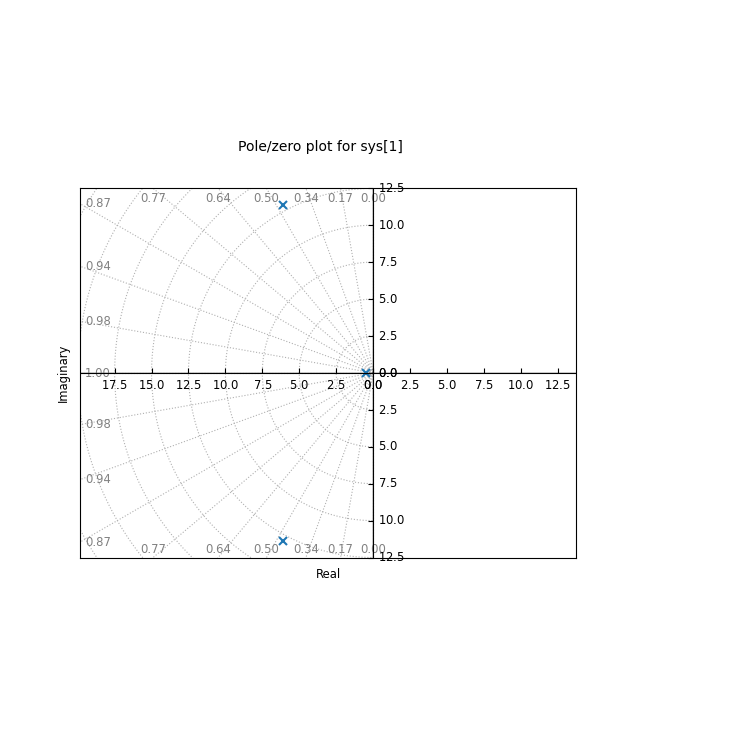

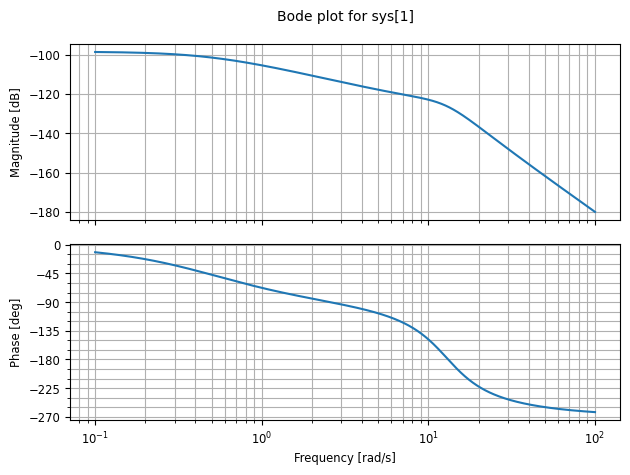

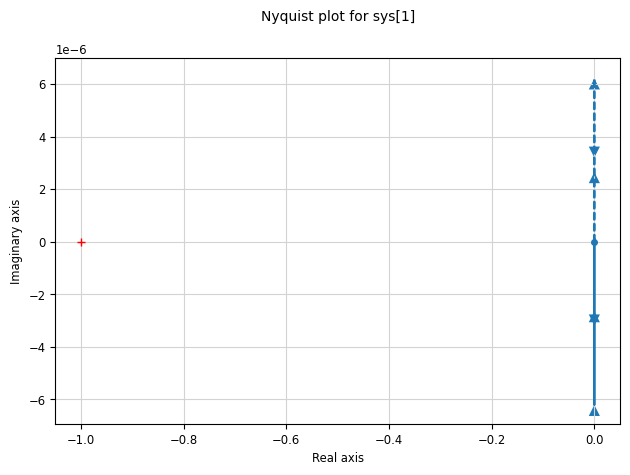

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


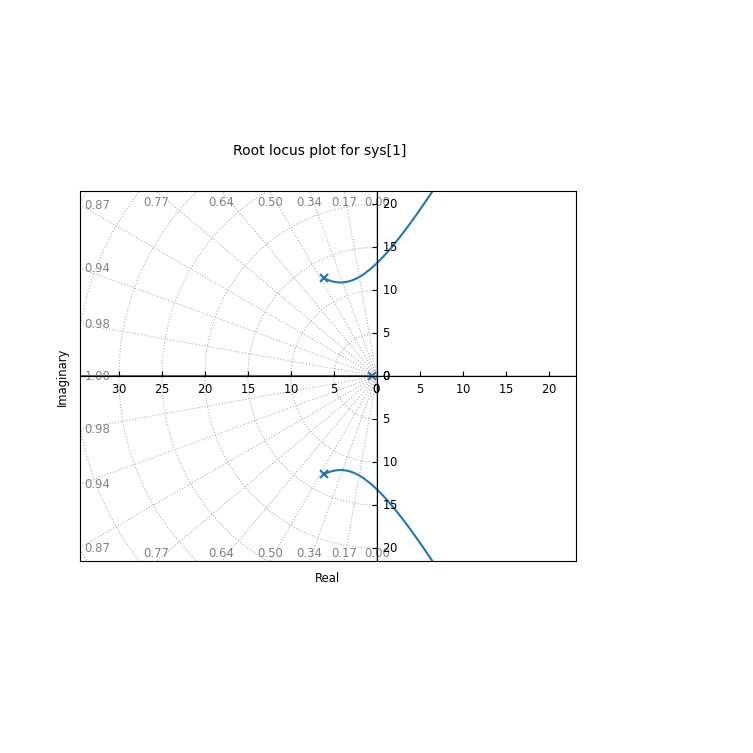

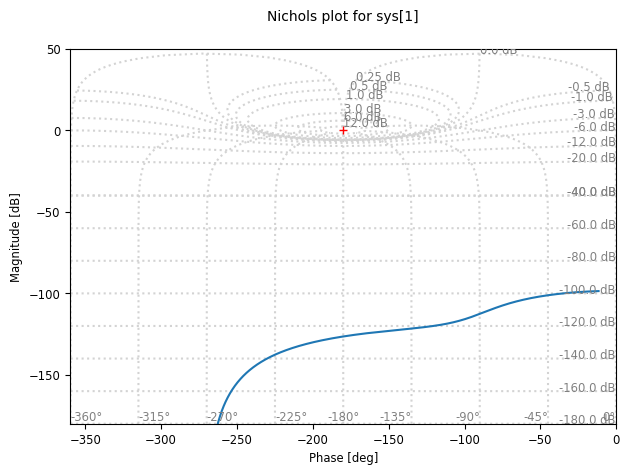

Margins: (np.float64(2101666.6665670318), inf, np.float64(13.133925536563698), nan)
[[  1.         172.5       ]
 [ 12.66666667  83.33333333]
 [165.92105263   0.        ]
 [ 83.33333333   0.        ]]
RHP roots: 0


In [3]:
Ap=30e-4; m=20; b=120; k=250; tau=.15; Kv=8e5
A=np.array([[0,1,0],[-k/m,-b/m,Ap/m],[0,-Kv,-1/tau]])
B=np.array([[0],[0],[1/tau]]); C=np.array([[1,0,0]]); D=np.array([[0]])
p=np.linalg.eigvals(A); print("Classification:",modal_label(p)); print("Poles:",p)
if HAS_CONTROL:
    G=ct.ss2tf(ct.ss(A,B,C,D)); print(G)
    print("Ctrb:",np.linalg.matrix_rank(ct.ctrb(A,B)),"Obsv:",np.linalg.matrix_rank(ct.obsv(A,C)))
    ct.pzmap(G,grid=True); plt.show(); ct.bode_plot(G,dB=True,grid=True); plt.show(); ct.nyquist_plot(G); plt.show(); ct.root_locus_plot(G,grid=True); plt.show()
    try: ct.nichols_plot(G,grid=True); plt.show()
    except Exception as e: print(e)
    print("Margins:",ct.margin(G))
Rtab,chg=routh_table(np.poly(A)); print(Rtab); print("RHP roots:",chg)

## Nonlinear compressible valve flow

In [4]:
def mdot(Pu,Pd,T,Aor,Cd=.7,gamma=1.4,R=287):
    Pu=max(Pu,1e3); Pd=max(Pd,1e3)
    if Pd>=Pu: return 0.
    pr=Pd/Pu; crit=(2/(gamma+1))**(gamma/(gamma-1))
    if pr<=crit:
        return Cd*Aor*Pu*np.sqrt(gamma/(R*T))*(2/(gamma+1))**((gamma+1)/(2*(gamma-1)))
    inside=(2*gamma/(R*T*(gamma-1)))*(pr**(2/gamma)-pr**((gamma+1)/gamma))
    return Cd*Aor*Pu*np.sqrt(max(inside,0))

def pneumatic_nonlinear(supply_bar=6,valve=.6,stroke=.5,bore_mm=63,rod_mm=25,dead_ml=50,mass=30,friction=40,leak_mm2=.05,tau_spool=.03):
    Ps=101325+supply_bar*1e5; Pa=101325; T=293.15; gamma=1.4; R=287
    A1=np.pi*(bore_mm/1000)**2/4; A2=np.pi*((bore_mm/1000)**2-(rod_mm/1000)**2)/4
    Vd=dead_ml*1e-6; Amax=8e-6; Aleak=leak_mm2*1e-6
    def f(t,y):
        x,v,P1,P2,z=y; dz=(np.clip(valve,-1,1)-z)/tau_spool; Av=Amax*abs(z)
        V1=max(Vd+A1*x,1e-7); V2=max(Vd+A2*(stroke-x),1e-7)
        if z>=0: m1=mdot(Ps,P1,T,Av); m2=-mdot(P2,Pa,T,Av)
        else: m1=-mdot(P1,Pa,T,Av); m2=mdot(Ps,P2,T,Av)
        ml=mdot(P1,P2,T,Aleak) if P1>P2 else -mdot(P2,P1,T,Aleak)
        m1-=ml; m2+=ml
        dP1=gamma*R*T/V1*m1-gamma*P1*A1/V1*v
        dP2=gamma*R*T/V2*m2+gamma*P2*A2/V2*v
        Fp=P1*A1-P2*A2-Pa*(A1-A2); Fc=friction*np.tanh(150*v); acc=(Fp-Fc)/mass
        if x<=0 and v<0: acc=max(acc,0)
        if x>=stroke and v>0: acc=min(acc,0)
        return [v,acc,dP1,dP2,dz]
    t=np.linspace(0,3,2200); sol=solve_ivp(f,[0,3],[stroke*.3,0,Pa,Pa,0],t_eval=t,method="Radau")
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[0]); plt.axhline(0,ls="--"); plt.axhline(stroke,ls="--"); plt.grid(True); plt.title("Position"); plt.show()
    plt.figure(figsize=(9,3)); plt.plot(t,(sol.y[2]-Pa)/1e5,label="P1"); plt.plot(t,(sol.y[3]-Pa)/1e5,label="P2"); plt.grid(True); plt.legend(); plt.ylabel("bar gauge"); plt.show()
widgets.interact(pneumatic_nonlinear,supply_bar=(2.,10.,.5),valve=(-1.,1.,.1),stroke=(.1,1.,.05),bore_mm=(20.,125.,1.),rod_mm=(5.,60.,1.),dead_ml=(5.,300.,5.),mass=(5.,100.,5.),friction=(0.,150.,5.),leak_mm2=(0.,.5,.01),tau_spool=(.005,.2,.005));

interactive(children=(FloatSlider(value=6.0, description='supply_bar', max=10.0, min=2.0, step=0.5), FloatSlid…

## PID with anti-windup, saturation, noise and disturbance

In [5]:
def pneu_pid(Kp=2.5,Ki=.8,Kd=.15,aw=5,ref=.3):
    Ap=30e-4; m=20; b=120; k=250; tau=.15; Kv=8e5; Plim=6e5
    def f(t,y):
        x,v,dp,I=y; e=ref-(x+.001*np.sin(30*t)); ur=(Kp*e+Ki*I-Kd*v)*1e6; u=np.clip(ur,-Plim,Plim)
        load=300+(150 if t>2 else 0)
        return [v,(Ap*dp-b*v-k*x-load)/m,(u-dp)/tau-Kv*v,e+aw*(u-ur)/1e6]
    t=np.linspace(0,5,1800); sol=solve_ivp(f,[0,5],[0,0,0,0],t_eval=t)
    plt.figure(figsize=(9,3)); plt.plot(t,sol.y[0]); plt.axhline(ref,ls="--"); plt.grid(True); plt.show()
widgets.interact(pneu_pid,Kp=(0.,10.,.1),Ki=(0.,5.,.1),Kd=(0.,2.,.05),aw=(0.,20.,1.),ref=(.05,.5,.05));

interactive(children=(FloatSlider(value=2.5, description='Kp', max=10.0), FloatSlider(value=0.8, description='…

## State feedback, observer, LQR and digital model

In [6]:
if HAS_CONTROL:
    Ksf=ct.place(A,B,[-3,-5,-8]); Lobs=ct.place(A.T,C.T,[-12,-15,-18]).T
    print("K:",Ksf); print("L:",Lobs)
    try: print("LQR:",ct.lqr(A,B,np.diag([100,5,1e-10]),np.array([[1e-10]])))
    except Exception as e: print(e)
Ad,Bd,Cd,Dd,_=signal.cont2discrete((A,B,C,D),.02)
print("Discrete poles:",np.linalg.eigvals(Ad)); print("Unit-circle stable?",np.all(abs(np.linalg.eigvals(Ad))<1))

K: [[-5.000e+03 -1.135e+05  5.000e-01]]
L: [[ 3.23333333e+01]
 [ 8.39444441e+01]
 [-1.71753086e+07]]
LQR: (array([[7.83362185e+05, 1.15486177e+05, 1.68269975e+00]]), array([[3.18707780e+01, 1.54537475e+00, 1.17504328e-05],
       [1.54537475e+00, 3.32114628e-01, 1.73229266e-06],
       [1.17504328e-05, 1.73229266e-06, 2.52404963e-11]]), array([ -3.55847694 +0.j        , -10.16309405+13.40430585j,
       -10.16309405-13.40430585j]))
Discrete poles: [0.99003442+0.j         0.86263263+0.19971801j 0.86263263-0.19971801j]
Unit-circle stable? True


## Numerical Jacobian and local stability

In [7]:
def simp(x):
    pos,v,dp=x; return np.array([v,(Ap*dp-b*v-k*pos)/m,-dp/tau-Kv*v])
x0=np.zeros(3); h=1e-6; J=np.zeros((3,3))
for i in range(3):
    xp=x0.copy(); xm=x0.copy(); xp[i]+=h; xm[i]-=h; J[:,i]=(simp(xp)-simp(xm))/(2*h)
print("Jacobian:\n",J); print("Local poles:",np.linalg.eigvals(J))

Jacobian:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-1.25000000e+01 -6.00000000e+00  1.50000000e-04]
 [ 0.00000000e+00 -8.00000000e+05 -6.66666667e+00]]
Local poles: [-0.50077845 +0.j         -6.08294411+11.37564839j
 -6.08294411-11.37564839j]


## Uncertainty sweep

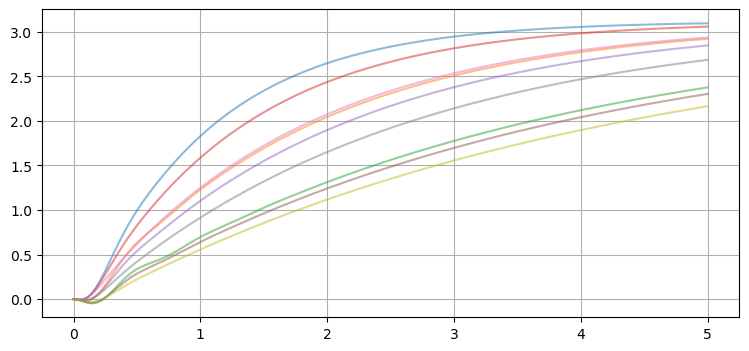

In [8]:
t=np.linspace(0,5,1300); plt.figure(figsize=(9,4))
for bt in [60,120,240]:
    for ttau in [.08,.15,.3]:
        def f(ti,y): x,v,dp=y; return [v,(Ap*dp-bt*v-k*x-300)/m,(3.6e5-dp)/ttau-Kv*v]
        sol=solve_ivp(f,[0,5],[0,0,0],t_eval=t); plt.plot(t,sol.y[0],alpha=.5)
plt.grid(True); plt.show()